# 패키지 및 데이터 로드

In [22]:
# ── 표준 라이브러리
import numpy as np

# ── 서드파티 라이브러리
import seaborn as sns
from matplotlib import pyplot as plt
from pandas import DataFrame

# ── 머신러닝 (scikit-learn)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance

# ── 사용자 정의 모듈
from hossam import *


### 성능평가 함수

In [ ]:
def hs_get_scores(estimator, x_test,y_true):
def (estimator, x_test, y_true):

_IncompleteInputError: incomplete input (4125691579.py, line 1)

### 데이터 로드

In [7]:
origin = load_data("restaurant_sales")


# 데이터 타입 변환 + 인덱스 설정
df1 = origin.astype(
    {
        "restaurant_type": "category",
        "holiday": "category",
        "weekend": "category",
    }
)

df1.set_index("date", inplace=True)

display(df1.info())
df1.head()





어느 식당의 1년간 일별 매출을 기록한 데이터로, 매출액을 종속변수로 하고 방문객 수, 객단가, 광고비, 날씨, 요일, 식당 유형 등의 정보를 포함함.

컬럼명           변수 타입    데이터 성격    설명
---------------  -----------  -------------  -------------------------------------------------------
date             날짜         시계열 인덱스  관측 날짜 (1년, 일 단위)
sales            연속형       수치           일 매출액 (종속변수). 이상치·왜도 존재 → 로그 변환 대상
visitors         연속형       수치           일 방문객 수. 매출과 강한 양의 관계
avg_price        연속형       수치           평균 객단가. 양의 왜도 → 로그 변환 권장
marketing_cost   연속형       수치           일 광고비 지출. 이상치·결측치 포함
delivery_ratio   연속형       비율           배달 매출 비중 (0~1). 비선형 효과 가능
rain_mm          연속형       수치           일 강수량(mm). 일부 결측치 존재
temperature      연속형       수치           일 평균 기온(℃). 계절성 반영
holiday          명목형       이진           공휴일 여부 (0=평일, 1=공휴일)
weekend          명목형       이진           주말 여부 (0=평일, 1=주말)
restaurant_type  명목형       범주           식당 유형 (한식/중식/양식/카페) → 원핫인코딩 필요

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2024-01-01 to 20

None

,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend,restaurant_type
date,,,,,,,,,,
2024-01-01,10525760,122,14490,9900.0,0.48,6.0,5.2,0,0,한식
2024-01-02,8931390,106,11880,9400.0,0.48,7.0,11.1,0,0,중식
2024-01-03,12654970,120,18010,5800.0,0.43,12.4,12.9,1,0,한식
2024-01-04,9650090,115,11160,6300.0,0.41,6.6,12.9,0,0,중식
2024-01-05,9951380,124,15480,5400.0,0.51,8.0,11.0,0,0,카페


### 훈련,검증 데이터 분리

In [10]:
# 원본 데이터
df = origin

# 타깃 / 피처 분리
y_name = "sales"
X = df.drop(columns=y_name)
y = df[y_name]

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=52,
)

# 데이터 크기 확인
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((273, 10), (92, 10), (273,), (92,))

### SVR 모델 적합
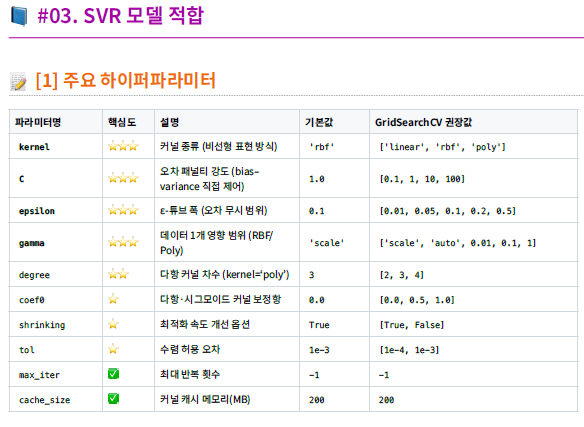

In [28]:
%%time

# ── 파이프라인 정의
pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", SVR()),
    ]
)

# ── 하이퍼파라미터 그리드
param_grid = {
    # 핵심 파라미터 (기본 rbf 커널)
    "model__kernel": ["rbf"],
    "model__C": [0.1, 1, 10, 100],
    "model__epsilon": [0.01, 0.05, 0.1, 0.2],
    "model__gamma": ["scale", "auto", 0.01, 0.1, 1],

    # poly 커널 실험 시 (비권장: 학습시간 증가)
    # "model__kernel": ["poly"],
    # "model__degree": [2, 3, 4],
    # "model__coef0": [0.0, 0.5, 1.0],
}

# ── GridSearchCV 설정
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# ── 학습
gs.fit(X_train, y_train)

# ── 최적 모델 및 결과 확인
best_model = gs.best_estimator_

print("Best params:", gs.best_params_)
print("CV best score:", gs.best_score_)





CPU times: total: 312 ms
Wall time: 3.22 s


ValueError: 
All the 400 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
400 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
  File "c:\Users\itwill\AppData\Local\Prog

In [30]:
from sklearn.compose import ColumnTransformer

num_cols = X_train.select_dtypes(include="number").columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", SVR()),
    ]
)


In [31]:
X_train.dtypes[X_train.dtypes == "object"]


restaurant_type    object
dtype: object

In [33]:
hs_get_scores(best_model, x_test, y_test)

NameError: name 'hs_get_scores' is not defined

In [29]:
score_df = DataFrame(
    [
        [
            "Linear",
            0.709,
            0.156,
            0.042,
            0.204,
            0.010,
            0.225,
            0.198,
            0.203,
            0.012,
            0.973,
            0.060,
            "⚠️ 판단 유보",
        ],
        [
            "Ridge",
            0.708,
            0.156,
            0.042,
            0.205,
            0.010,
            0.219,
            0.198,
            0.203,
            0.012,
            0.974,
            0.058,
            "⚠️ 판단 유보",
        ],
        [
            "Lasso",
            0.707,
            0.155,
            0.042,
            0.205,
            0.009,
            0.221,
            0.199,
            0.204,
            0.011,
            0.978,
            0.055,
            "⚠️ 판단 유보",
        ],
        [
            "ElasticNet",
            0.709,
            0.156,
            0.042,
            0.204,
            0.010,
            0.223,
            0.198,
            0.203,
            0.012,
            0.974,
            0.059,
            "⚠️ 판단 유보",
        ],
        [
            "SGD",
            0.700,
            0.160,
            0.043,
            0.207,
            0.010,
            0.229,
            0.203,
            0.210,
            0.010,
            0.964,
            0.046,
            "⚠️ 판단 유보",
        ],
        [
            "KNN",
            0.635,
            0.178,
            0.052,
            0.229,
            0.011,
            0.301,
            0.000,
            0.220,
            0.020,
            0.000,
            0.090,
            "⚠️ 과대적합 (variance 큼)",
        ],
        [
            "DecisionTree",
            0.620,
            0.196,
            0.054,
            0.233,
            0.012,
            0.353,
            0.224,
            0.245,
            0.018,
            0.912,
            0.072,
            "✅ 일반화 양호",
        ],
        [
            "SVR",
            0.701,
            0.157,
            0.043,
            0.207,
            0.010,
            0.233,
            0.196,
            0.206,
            0.011,
            0.949,
            0.055,
            "✅ 일반화 양호",
        ],
    ],
    columns=[
        "모델",
        "결정계수(R2)",
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "MPE",
        "Train RMSE",
        "CV RMSE 평균",
        "CV RMSE 표준편차",
        "Train/CV 비율",
        "CV 변동성 비율",
        "판정 결과",
    ],
)
score_df

,모델,결정계수(R2),MAE,MSE,RMSE,MAPE,MPE,Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
0,Linear,0.709,0.156,0.042,0.204,0.010,0.225,0.198,0.203,0.012,0.973,0.060,⚠️ 판단 유보
1,Ridge,0.708,0.156,0.042,0.205,0.010,0.219,0.198,0.203,0.012,0.974,0.058,⚠️ 판단 유보
2,Lasso,0.707,0.155,0.042,0.205,0.009,0.221,0.199,0.204,0.011,0.978,0.055,⚠️ 판단 유보
3,ElasticNet,0.709,0.156,0.042,0.204,0.010,0.223,0.198,0.203,0.012,0.974,0.059,⚠️ 판단 유보
4,SGD,0.700,0.160,0.043,0.207,0.010,0.229,0.203,0.210,0.010,0.964,0.046,⚠️ 판단 유보
5,KNN,0.635,0.178,0.052,0.229,0.011,0.301,0.000,0.220,0.020,0.000,0.090,⚠️ 과대적합 (variance 큼)
6,DecisionTree,0.620,0.196,0.054,0.233,0.012,0.353,0.224,0.245,0.018,0.912,0.072,✅ 일반화 양호
7,SVR,0.701,0.157,0.043,0.207,0.010,0.233,0.196,0.206,0.011,0.949,0.055,✅ 일반화 양호
